# KPIs do Sistema de Suporte à Decisão — Previsão de Reincidência

**Projeto:** DSS para Previsão de Reincidência Criminal  
**Dados:** NIJ Recidivism Forecasting Challenge (Georgia, EUA, 2013–2015)

---

## Objetivo desta análise

Métricas técnicas como Acurácia, AUC-ROC e KS medem a qualidade discriminativa do modelo, mas não respondem à pergunta mais importante para a gestão pública:

> **Quanto vale, em dólares e em vidas, implantar este sistema?**

Esta análise traduz o desempenho técnico em **KPIs de negócio** — indicadores que quantificam o impacto social do DSS em função do **ponto de operação** (limiar de corte θ do score).

### Conceito central: ponto de operação (θ)

O modelo atribui a cada indivíduo um score $P(\text{Não Reincidiu})$ entre 0 e 1. O limiar θ define a decisão binária:

- **Score < θ** → classificado como **ALTO RISCO** (prediz reincidência) → supervisão intensiva  
- **Score ≥ θ** → classificado como **BAIXO RISCO** (prediz não-reincidência) → supervisão padrão

Ao variar θ de 0 a 1 controlamos o trade-off entre detectar reincidentes e evitar supervisão desnecessária. O padrão em machine learning é θ = 0,50, mas o ponto ótimo para os KPIs de negócio raramente é 50%.

### KPIs definidos

| # | KPI | O que mede |
|---|-----|------------|
| 1 | Sensibilidade e Especificidade | Taxa de detecção de risco vs. falsos alarmes |
| 2 | Reincidências e Hospitalizações Evitadas | Impacto concreto em segurança e saúde pública |
| 3 | **Valor Líquido Agregado** | KPI síntese: benefício social − custo operacional |


In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score

plt.rcParams.update({'figure.dpi': 110, 'axes.titlesize': 11,
                     'axes.labelsize': 10, 'axes.spines.top': False,
                     'axes.spines.right': False})


In [29]:
# =============================================================================
# LEITURA E PREPARAÇÃO DOS DADOS
# Carregar dados já transformados
# =============================================================================

ARQUIVO = 'dados/dados_transformados.csv'   # ajuste o caminho se necessário
LABEL   = 'Recidivism_Within_3years'
SEED    = 42

df = pd.read_csv(ARQUIVO)

print(f"Dataset: {df.shape[0]:,} registros × {df.shape[1]} colunas")
print(f"\nDistribuição da variável resposta:")
vc = df[LABEL].value_counts().sort_index()
print(f"  0 — Reincidiu      : {vc[0]:>6,} ({vc[0]/len(df)*100:.1f}%)")
print(f"  1 — Não Reincidiu  : {vc[1]:>6,} ({vc[1]/len(df)*100:.1f}%)")


Dataset: 25,835 registros × 44 colunas

Distribuição da variável resposta:
  0 — Reincidiu      : 14,904 (57.7%)
  1 — Não Reincidiu  : 10,931 (42.3%)


In [30]:
# =============================================================================
# TREINAR MODELO (Regressão Logística — modelo principal do projeto)
# =============================================================================

FEATURES = [c for c in df.columns if c != LABEL]
X, y     = df[FEATURES], df[LABEL]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=SEED, stratify=y
)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

# Modelo com regularização L1 (C=0.003 — selecionado na análise anterior)
lr = LogisticRegression(
    penalty='l1', solver='liblinear', C=0.003,
    random_state=SEED, max_iter=1000
)
lr.fit(X_train_sc, y_train)

# Scores de probabilidade no conjunto de teste
y_proba = lr.predict_proba(X_test_sc)[:, 1]   # P(Não Reincidiu)
y_true  = y_test.values

auc = roc_auc_score(y_test, y_proba)
print(f"Conjunto de teste : {len(y_true):,} registros")
print(f"Reincidentes      : {(y_true==0).sum():,} ({(y_true==0).mean()*100:.1f}%)")
print(f"Não Reincidentes  : {(y_true==1).sum():,} ({(y_true==1).mean()*100:.1f}%)")
print(f"AUC-ROC           : {auc:.4f}")
print(f"\nScore mín={y_proba.min():.3f} | máx={y_proba.max():.3f} | média={y_proba.mean():.3f}")


Conjunto de teste : 7,751 registros
Reincidentes      : 4,471 (57.7%)
Não Reincidentes  : 3,280 (42.3%)
AUC-ROC           : 0.7384

Score mín=0.099 | máx=0.893 | média=0.442


## 1. Parâmetros de Custo

Todos os valores são em **dólares americanos (USD, referência 2014–2015)**, alinhados com o período e localização dos dados (Georgia, EUA, 2013–2015).

### Composição do custo social por reincidência

O custo por reincidência inclui toda a cadeia de resposta do sistema criminal:

| Componente | Valor (USD 2015) | Fonte |
|---|---|---|
| Encarceramento (média 2,5 anos × US$ 22.000/ano) | US$ 55.000 | Vera Institute of Justice (2017) — estados do Sul |
| Custos judiciais e de processo | US$ 10.000 | Bureau of Justice Statistics (2016) |
| Custos de aplicação da lei | US$ 5.000 | BJS (2016) |
| Custos tangíveis à vítima (médicos, perda de salário) | US$ 8.000 | McCollister, French & Fang (2010) — tangíveis |
| **Total conservador** | **US$ 78.000** | — |

> Optamos pelo valor conservador (sem custos intangíveis de dor e sofrimento) para maior defensabilidade acadêmica. McCollister et al. (2010) estimam US$ 107.000 para agressão grave incluindo intangíveis.

### Custo de supervisão

Supervisão padrão (probation/parole): ~US$ 1.500/ano. Supervisão intensiva (monitoramento eletrônico + visitas frequentes): ~US$ 7.500/ano. Custo incremental: **US$ 6.000/ano por pessoa**.

### Referências

- **McCollister, K.E., French, M.T., & Fang, H. (2010).** The cost of crime to society. *Drug and Alcohol Dependence*, 108(1-2), 98–109.
- **Vera Institute of Justice (2017).** The Price of Prisons: Examining State Spending Trends, 2010–2015.
- **Bureau of Justice Statistics (2016).** Justice Expenditure and Employment Extracts, 2012.
- **National Institute of Justice (2022).** Community Corrections. https://bjs.ojp.gov/topics/corrections/community-corrections
- **Aos, S., Miller, M., & Drake, E. (2011).** Evidence-based adult corrections programs. Washington State Institute for Public Policy.


In [31]:
# =============================================================================
# PARÂMETROS DE CUSTO
# Valores em USD (dólares americanos, referência 2014–2015)
#
# FONTES:
# [1] McCollister, French & Fang (2010). Drug and Alcohol Dependence, 108(1-2).
# [2] Vera Institute of Justice (2017). Price of Prisons 2015.
# [3] Bureau of Prisons / DOJ (2015). Federal Register, March 9, 2015.
# [4] National Institute of Justice (2022). Community Corrections.
# [5] Aos, Miller & Drake (2011). Washington State Institute for Public Policy.
# =============================================================================

CUSTOS = {
    # Custo social médio por reincidência grave (conservador — sem intangíveis)
    # Encarceramento ($55k) + judicial ($10k) + policial ($5k) + vítima tangível ($8k)
    'custo_por_reincidencia'      : 78_000,   # USD por evento  [1][2][3]

    # Custo INCREMENTAL de supervisão intensiva vs. padrão por ano
    # Intensiva (~$7.500/ano) - Padrão (~$1.500/ano) = $6.000 incremental  [4]
    'custo_incremental_supervisao': 6_000,    # USD/pessoa/ano

    # Taxa de prevenção: % de reincidências evitadas pela supervisão intensiva
    # Meta-análise de programas de supervisão comunitária  [5]
    'taxa_prevencao'              : 0.30,     # 30%

    # Taxa de hospitalização: % de reincidências que geram internação hospitalar
    # (mantida apenas para o KPI 2 de saúde pública)
    'taxa_vitima_hospitalizacao'  : 0.15,     # 15%

    # Custo médio de internação hospitalar por vítima de crime violento
    # Diária ~US$ 2.500 × 3 dias médios  [4]
    'custo_hospitalar_por_vitima' : 7_500,    # USD por vítima
}

PERIODO_ANOS = 3   # período de análise (anos de supervisão cobertos)

# Benefício por reincidência evitada (usado no KPI 3 — Valor Líquido)
# Inclui apenas o custo do crime, sem hospitalização
BENEF_POR_REINC = CUSTOS['custo_por_reincidencia'] * CUSTOS['taxa_prevencao']

print("Parâmetros de custo — USD (referência 2014–2015):")
print(f"  Custo por reincidência grave       : US$ {CUSTOS['custo_por_reincidencia']:>8,.0f}  [McCollister et al., 2010 + BJS]")
print(f"  Custo incremental de supervisão    : US$ {CUSTOS['custo_incremental_supervisao']:>8,.0f}/ano  [NIJ, 2022]")
print(f"  Taxa de prevenção                  :     {CUSTOS['taxa_prevencao']*100:>7.0f}%  [Aos et al., 2011]")
print(f"  Taxa de hospitalização (KPI 2)     :     {CUSTOS['taxa_vitima_hospitalizacao']*100:>7.0f}%")
print(f"  Custo hospitalar por vítima (KPI 2): US$ {CUSTOS['custo_hospitalar_por_vitima']:>8,.0f}")
print(f"  Período de análise                 :     {PERIODO_ANOS:>7} anos")
print()
print(f"Benefício por reincidência evitada   : US$ {BENEF_POR_REINC:>8,.0f}")
print(f"Custo de supervisão por pessoa (3a)  : US$ {CUSTOS['custo_incremental_supervisao']*PERIODO_ANOS:>8,.0f}")
print(f"Breakeven (precisão mínima)          :     {CUSTOS['custo_incremental_supervisao']*PERIODO_ANOS/BENEF_POR_REINC*100:>7.1f}%")


Parâmetros de custo — USD (referência 2014–2015):
  Custo por reincidência grave       : US$   78,000  [McCollister et al., 2010 + BJS]
  Custo incremental de supervisão    : US$    6,000/ano  [NIJ, 2022]
  Taxa de prevenção                  :          30%  [Aos et al., 2011]
  Taxa de hospitalização (KPI 2)     :          15%
  Custo hospitalar por vítima (KPI 2): US$    7,500
  Período de análise                 :           3 anos

Benefício por reincidência evitada   : US$   23,400
Custo de supervisão por pessoa (3a)  : US$   18,000
Breakeven (precisão mínima)          :        76.9%


## 2. Cálculo dos KPIs por Limiar de Corte

Para cada valor de θ entre 0 e 1, calculamos os 3 KPIs.  
O KPI síntese é o **Valor Líquido Agregado**:

$$\text{VLA}(\theta) = \underbrace{TP(\theta) \cdot C_{crime} \cdot r_{prev}}_{\text{Benefício social}} - \underbrace{(TP + FP)(\theta) \cdot \Delta C_{sup} \cdot T}_{\text{Custo operacional}}$$

Onde:
- $TP(\theta)$ = reincidentes corretamente identificados no limiar θ
- $C_{crime}$ = custo social por reincidência (US$ 78.000)
- $r_{prev}$ = taxa de prevenção (30%)
- $\Delta C_{sup}$ = custo incremental de supervisão intensiva (US$ 6.000/ano)
- $T$ = período de análise (3 anos)


In [32]:
# =============================================================================
# CÁLCULO DOS KPIs PARA TODOS OS LIMIARES
# Para cada θ: calcula TP, FP, TN, FN e os 3 KPIs de negócio
# =============================================================================

thresholds  = np.linspace(0.01, 0.99, 500)
n_total     = len(y_true)
n_reincid   = int((y_true == 0).sum())
n_nao_reinc = int((y_true == 1).sum())

resultados = []
for t in thresholds:
    # score < θ → ALTO RISCO → supervisão intensiva
    pred_alto = (y_proba < t)

    TP = int(((pred_alto) & (y_true == 0)).sum())
    FP = int(((pred_alto) & (y_true == 1)).sum())
    TN = int(((~pred_alto) & (y_true == 1)).sum())
    FN = int(((~pred_alto) & (y_true == 0)).sum())
    n_sup = TP + FP

    # ── KPI 1: Sensibilidade e Especificidade ─────────────────────────────
    kpi1_sensib = TP / n_reincid   if n_reincid  > 0 else 0
    kpi1_espec  = TN / n_nao_reinc if n_nao_reinc > 0 else 0

    # ── KPI 2: Reincidências e Hospitalizações Evitadas ───────────────────
    kpi2_reinc_evit = TP * CUSTOS['taxa_prevencao']
    kpi2_hosp_evit  = kpi2_reinc_evit * CUSTOS['taxa_vitima_hospitalizacao']

    # ── KPI 3: Valor Líquido Agregado ─────────────────────────────────────
    beneficio       = TP * BENEF_POR_REINC
    custo_op        = n_sup * CUSTOS['custo_incremental_supervisao'] * PERIODO_ANOS
    kpi3_vliq       = beneficio - custo_op

    resultados.append({
        'threshold'        : t,
        'TP': TP, 'FP': FP, 'TN': TN, 'FN': FN,
        'n_supervisionados': n_sup,
        'pct_sup'          : n_sup / n_total * 100,
        'kpi1_sensib'      : kpi1_sensib,
        'kpi1_espec'       : kpi1_espec,
        'kpi2_reinc_evit'  : kpi2_reinc_evit,
        'kpi2_hosp_evit'   : kpi2_hosp_evit,
        'kpi3_benef_MM'    : beneficio  / 1e6,
        'kpi3_custo_MM'    : custo_op   / 1e6,
        'kpi3_vliq_MM'     : kpi3_vliq  / 1e6,
    })

df_kpi = pd.DataFrame(resultados)

idx_opt = df_kpi['kpi3_vliq_MM'].idxmax()
idx_t50 = (df_kpi['threshold'] - 0.50).abs().idxmin()
T_OTIMO = df_kpi.loc[idx_opt, 'threshold']

print(f"Threshold padrão (0.5) : θ = 0.500")
print(f"Threshold ótimo (VLA)  : θ = {T_OTIMO:.3f}")


Threshold padrão (0.5) : θ = 0.500
Threshold ótimo (VLA)  : θ = 0.297


## 3. KPIs por Ponto de Operação

Os três gráficos a seguir mostram, para cada valor de limiar de corte θ, o impacto do sistema nos três KPIs selecionados. As linhas verticais tracejadas marcam dois pontos de referência:

- **θ = 0,50** (cinza): threshold padrão, usado sem otimização
- **θ ótimo** (verde): threshold que maximiza o Valor Líquido Agregado


### KPI 1 — Taxa de Detecção de Risco

**Definição:**
- **Sensibilidade** = TP / (TP + FN): dos reincidentes reais, qual % o sistema identifica corretamente como alto risco
- **Especificidade** = TN / (TN + FP): dos não-reincidentes reais, qual % é corretamente liberado da supervisão intensiva

**Como interpretar:**
As duas curvas se movem em direções opostas — aumentar a sensibilidade sempre custa especificidade. Esse é o trade-off fundamental do ponto de operação.

- O **ponto de cruzamento** (onde sensibilidade = especificidade) representa o threshold onde os dois tipos de erro são iguais
- Thresholds **à esquerda** do cruzamento: especificidade maior — o sistema é conservador, supervisiona menos pessoas, mas perde mais reincidentes
- Thresholds **à direita** do cruzamento: sensibilidade maior — o sistema é agressivo, supervisiona mais pessoas, captura mais reincidentes mas gera mais falsos alarmes

**Decisão operacional:** a escolha do threshold depende do que o gestor prioriza. Não existe resposta única — depende do orçamento disponível e da tolerância a erros de cada tipo.


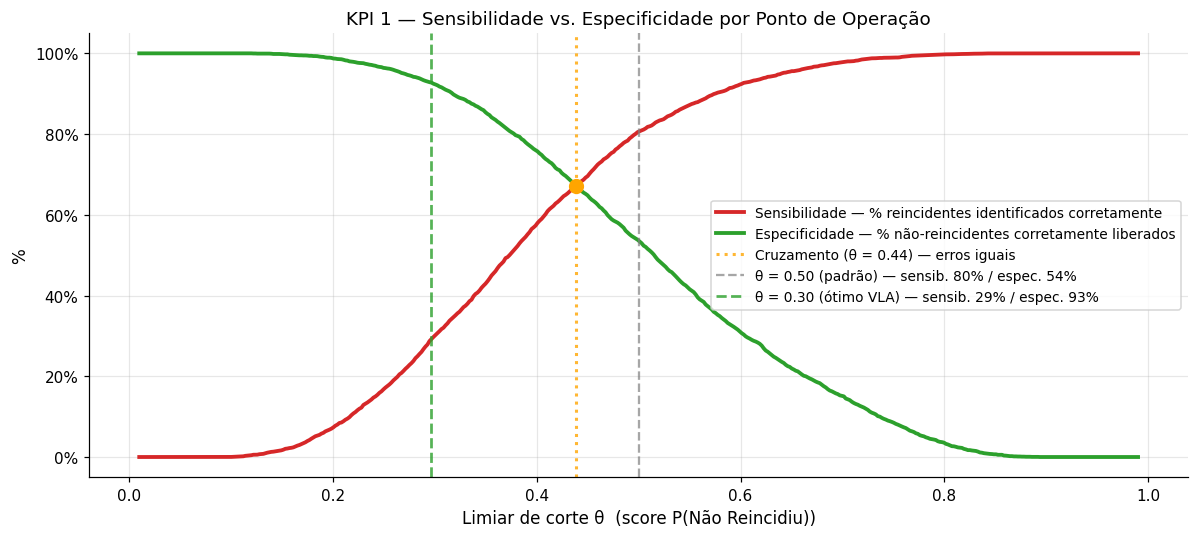

Threshold 0.50 : Sensibilidade = 80.5% | Especificidade = 53.8%
Threshold 0.30: Sensibilidade = 29.2% | Especificidade = 92.7%
Cruzamento     : theta = 0.44 (67.1% para ambas)


In [33]:
# =============================================================================
# KPI 1 — Sensibilidade e Especificidade por Ponto de Operação
# =============================================================================

fig, ax = plt.subplots(figsize=(11, 5))

ax.plot(df_kpi['threshold'], df_kpi['kpi1_sensib'] * 100,
        color='#d62728', linewidth=2.5,
        label='Sensibilidade — % reincidentes identificados corretamente')
ax.plot(df_kpi['threshold'], df_kpi['kpi1_espec'] * 100,
        color='#2ca02c', linewidth=2.5,
        label='Especificidade — % não-reincidentes corretamente liberados')

# Ponto de cruzamento
diff   = np.abs(df_kpi['kpi1_sensib'] - df_kpi['kpi1_espec'])
t_cruz = df_kpi.loc[diff.idxmin(), 'threshold']
y_cruz = df_kpi.loc[diff.idxmin(), 'kpi1_sensib'] * 100
ax.axvline(t_cruz, color='orange', linestyle=':', linewidth=2, alpha=0.8,
           label=f'Cruzamento (\u03b8 = {t_cruz:.2f}) — erros iguais')
ax.scatter([t_cruz], [y_cruz], color='orange', zorder=6, s=80)

# Pontos de referência
v_sensib_50   = df_kpi.loc[idx_t50,  'kpi1_sensib'] * 100
v_sensib_opt  = df_kpi.loc[idx_opt,  'kpi1_sensib'] * 100
v_espec_50    = df_kpi.loc[idx_t50,  'kpi1_espec']  * 100
v_espec_opt   = df_kpi.loc[idx_opt,  'kpi1_espec']  * 100

ax.axvline(0.5,     color='gray',    linestyle='--', linewidth=1.5, alpha=0.7,
           label=f'\u03b8 = 0.50 (padr\u00e3o) — sensib. {v_sensib_50:.0f}% / espec. {v_espec_50:.0f}%')
ax.axvline(T_OTIMO, color='#2ca02c', linestyle='--', linewidth=1.8, alpha=0.8,
           label=f'\u03b8 = {T_OTIMO:.2f} (\u00f3timo VLA) — sensib. {v_sensib_opt:.0f}% / espec. {v_espec_opt:.0f}%')

ax.set_xlabel('Limiar de corte \u03b8  (score P(N\u00e3o Reincidiu))', fontsize=11)
ax.set_ylabel('%', fontsize=11)
ax.set_title('KPI 1 — Sensibilidade vs. Especificidade por Ponto de Opera\u00e7\u00e3o', fontsize=12)
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.legend(fontsize=9, loc='center right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Threshold 0.50 : Sensibilidade = {v_sensib_50:.1f}% | Especificidade = {v_espec_50:.1f}%")
print(f"Threshold {T_OTIMO:.2f}: Sensibilidade = {v_sensib_opt:.1f}% | Especificidade = {v_espec_opt:.1f}%")
print(f"Cruzamento     : theta = {t_cruz:.2f} ({y_cruz:.1f}% para ambas)")


### KPI 2 — Reincidências e Hospitalizações Evitadas

**Definição:**

$$\text{Reincidencias evitadas}(\theta) = TP(\theta) \times r_{prev}$$

$$\text{Hospitaliza\c{c}oes evitadas}(\theta) = \text{Reincidencias evitadas}(\theta) \times r_{hosp}$$

Onde $r_{prev} = 30\%$ (Aos et al., 2011) e $r_{hosp} = 15\%$ (proporção de crimes que geram internação hospitalar).

**Como interpretar:**
Os dois gráficos são apresentados separadamente para facilitar a leitura. Ambas as curvas sobem com θ — supervisionar mais pessoas captura mais reincidentes e evita mais crimes. O crescimento é decrescente: os primeiros supervisionados são os de maior risco, cada um adicionado gera maior impacto marginal.

- **Reincidências evitadas** responde diretamente à questão de segurança pública
- **Hospitalizações evitadas** conecta o DSS à política de saúde — cada reincidência violenta evitada poupa leitos e custos hospitalares

**Premissa crítica:** a taxa de prevenção de 30% é estimada por meta-análise. Se a supervisão for mal executada, essa taxa pode ser menor — a análise de sensibilidade (Seção 5) mostra o impacto dessa variação.


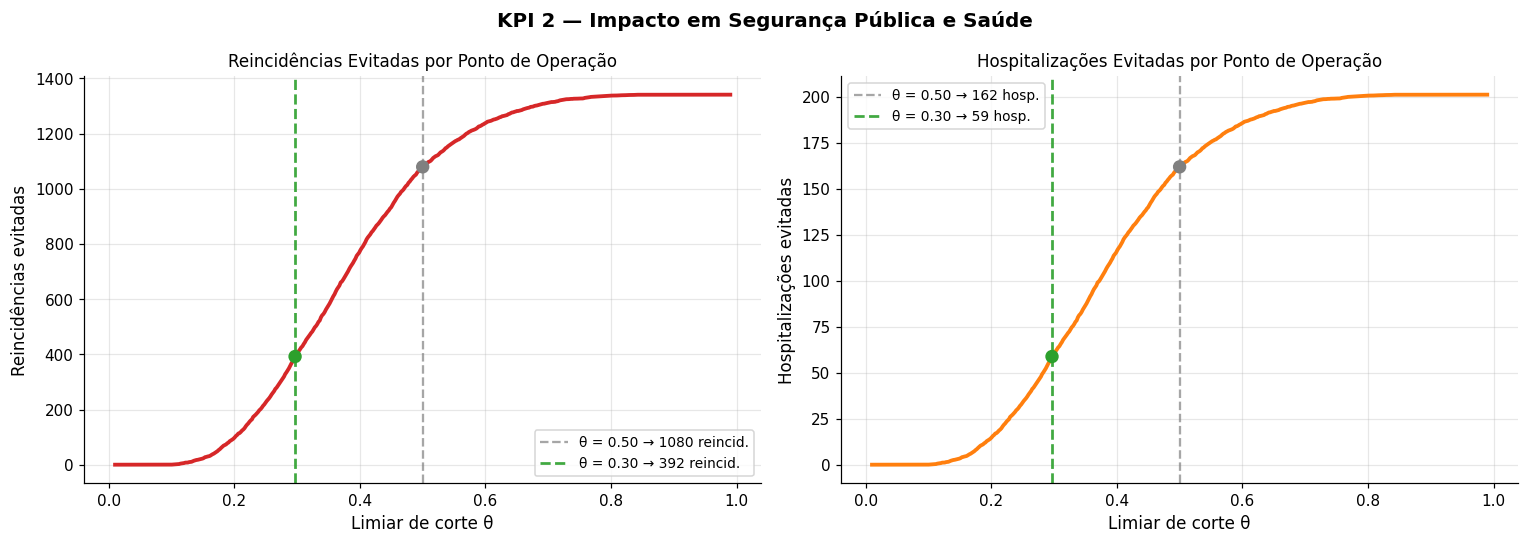

Threshold 0.50 : 1080 reincid. evitadas | 162 hospitaliz. evitadas
Threshold 0.30: 392 reincid. evitadas | 59 hospitaliz. evitadas
Taxa de prevencao assumida : 30%  (Aos et al., 2011)
Taxa de hospitalizacao     : 15%


In [34]:
# =============================================================================
# KPI 2 — Reincidências e Hospitalizações Evitadas (gráficos separados)
# =============================================================================

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('KPI 2 — Impacto em Segurança Pública e Saúde', fontsize=13, fontweight='bold')

r50  = df_kpi.loc[idx_t50, 'kpi2_reinc_evit']
ropt = df_kpi.loc[idx_opt, 'kpi2_reinc_evit']
h50  = df_kpi.loc[idx_t50, 'kpi2_hosp_evit']
hopt = df_kpi.loc[idx_opt, 'kpi2_hosp_evit']

# ── Gráfico A: Reincidências Evitadas ────────────────────────────────────────
ax1.plot(df_kpi['threshold'], df_kpi['kpi2_reinc_evit'],
         color='#d62728', linewidth=2.5)
ax1.axvline(0.5,     color='gray',    linestyle='--', linewidth=1.5, alpha=0.7,
            label=f'θ = 0.50 → {r50:.0f} reincid.')
ax1.axvline(T_OTIMO, color='#2ca02c', linestyle='--', linewidth=1.8, alpha=0.9,
            label=f'θ = {T_OTIMO:.2f} → {ropt:.0f} reincid.')
ax1.scatter([0.5, T_OTIMO], [r50, ropt], color=['gray', '#2ca02c'], zorder=5, s=60)
ax1.set_xlabel('Limiar de corte θ', fontsize=11)
ax1.set_ylabel('Reincidências evitadas', fontsize=11)
ax1.set_title('Reincidências Evitadas por Ponto de Operação', fontsize=11)
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.3)

# ── Gráfico B: Hospitalizações Evitadas ──────────────────────────────────────
ax2.plot(df_kpi['threshold'], df_kpi['kpi2_hosp_evit'],
         color='#ff7f0e', linewidth=2.5)
ax2.axvline(0.5,     color='gray',    linestyle='--', linewidth=1.5, alpha=0.7,
            label=f'θ = 0.50 → {h50:.0f} hosp.')
ax2.axvline(T_OTIMO, color='#2ca02c', linestyle='--', linewidth=1.8, alpha=0.9,
            label=f'θ = {T_OTIMO:.2f} → {hopt:.0f} hosp.')
ax2.scatter([0.5, T_OTIMO], [h50, hopt], color=['gray', '#2ca02c'], zorder=5, s=60)
ax2.set_xlabel('Limiar de corte θ', fontsize=11)
ax2.set_ylabel('Hospitalizações evitadas', fontsize=11)
ax2.set_title('Hospitalizações Evitadas por Ponto de Operação', fontsize=11)
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Threshold 0.50 : {r50:.0f} reincid. evitadas | {h50:.0f} hospitaliz. evitadas")
print(f"Threshold {T_OTIMO:.2f}: {ropt:.0f} reincid. evitadas | {hopt:.0f} hospitaliz. evitadas")
print(f"Taxa de prevencao assumida : {CUSTOS['taxa_prevencao']*100:.0f}%  (Aos et al., 2011)")
print(f"Taxa de hospitalizacao     : {CUSTOS['taxa_vitima_hospitalizacao']*100:.0f}%")


### KPI 3 — Valor Líquido Agregado

**Definição:**

$$\text{VLA}(\theta) = \underbrace{TP(\theta) \cdot r_{prev} \cdot (C_{crime} + r_{hosp} \cdot C_{hosp})}_{\text{Benef\'{i}cio social}} - \underbrace{N_{sup}(\theta) \cdot \Delta C_{sup} \cdot T}_{\text{Custo operacional}}$$

Onde $N_{sup} = TP + FP$ é o total de pessoas supervisionadas intensivamente, $\Delta C_{sup}$ é o custo incremental anual e $T$ o período de análise.

**Como interpretar:**
Este é o KPI síntese — coloca benefício e custo na mesma escala e responde à pergunta central: *em qual configuração o sistema gera mais valor líquido para a sociedade?*

- A curva começa em zero (ninguém supervisionado = sem custo e sem benefício)
- **Sobe** enquanto cada novo supervisionado adicionado é principalmente um verdadeiro positivo — o benefício marginal supera o custo marginal
- Atinge o **pico no threshold ótimo** — o ponto onde adicionar mais um supervisionado gera benefício igual ao custo
- **Cai** após o pico porque os novos supervisionados são cada vez mais falsos positivos — custo sem retorno
- A **zona verde** indica valor líquido positivo; a **zona vermelha** indica que o custo supera o benefício

**Ponto de equilíbrio (breakeven):** o threshold mínimo a partir do qual o sistema começa a gerar valor positivo. Abaixo disso, o DSS não é economicamente justificável.

**Diferença entre threshold de máximo VLA e threshold de máximo ROI:** o threshold de máximo VLA maximiza o impacto absoluto; o threshold de máximo ROI maximiza o retorno percentual. São objetivos diferentes — o gestor escolhe conforme a política pública prioritária.


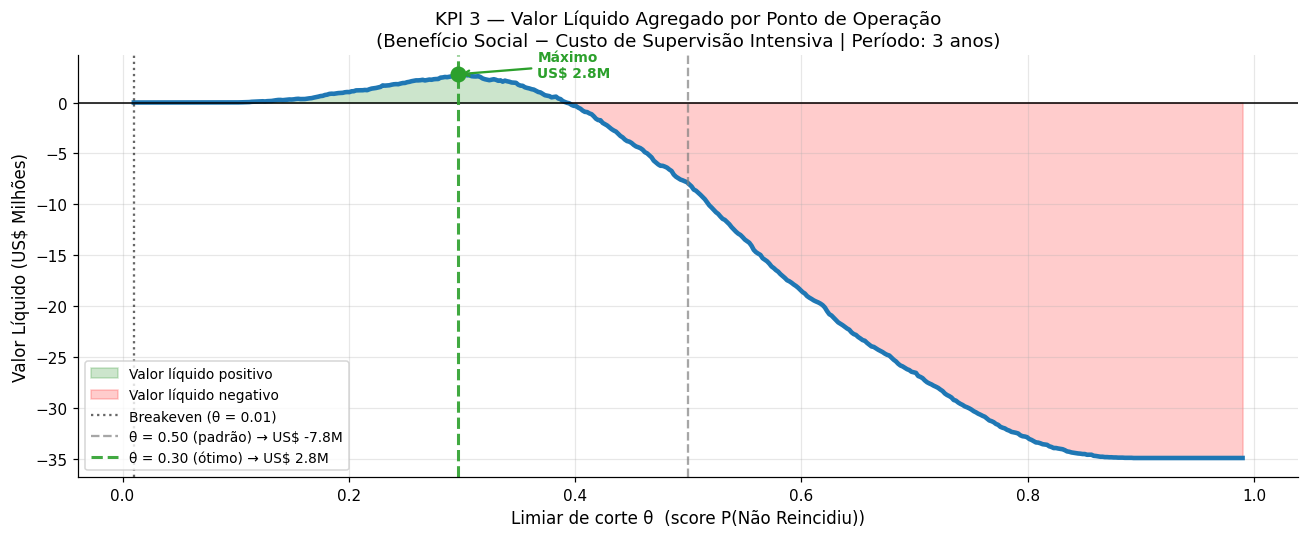

Resumo — KPI 3 (Valor Liquido Agregado)
  Threshold padrao  (0.50): US$      -8M
  Threshold otimo (0.30): US$       3M
  Breakeven               : theta = 0.01
  Custo por reincidencia  : US$ 78,000
  Custo incremental sup.  : US$ 6,000/ano
  Periodo de analise      : 3 anos


In [40]:
# =============================================================================
# KPI 3 — Valor Liquido Agregado por Ponto de Operacao
# =============================================================================

fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(df_kpi['threshold'], df_kpi['kpi3_vliq_MM'],
        color='#1f77b4', linewidth=3)

ax.fill_between(df_kpi['threshold'], df_kpi['kpi3_vliq_MM'], 0,
                where=(df_kpi['kpi3_vliq_MM'] >= 0),
                alpha=0.20, color='green', label='Valor l\u00edquido positivo')
ax.fill_between(df_kpi['threshold'], df_kpi['kpi3_vliq_MM'], 0,
                where=(df_kpi['kpi3_vliq_MM'] < 0),
                alpha=0.20, color='red', label='Valor l\u00edquido negativo')

ax.axhline(0, color='black', linewidth=1)

vliq_t50 = df_kpi.loc[idx_t50, 'kpi3_vliq_MM']
vliq_opt = df_kpi.loc[idx_opt, 'kpi3_vliq_MM']

# Ponto de equilibrio (breakeven)
diff_be = np.abs(df_kpi['kpi3_vliq_MM'])
zero_cross = df_kpi[df_kpi['kpi3_vliq_MM'] >= 0]['threshold'].min()
ax.axvline(zero_cross, color='black', linestyle=':', linewidth=1.5, alpha=0.6,
           label=f'Breakeven (\u03b8 = {zero_cross:.2f})')

ax.axvline(0.5,     color='gray',    linestyle='--', linewidth=1.5, alpha=0.7,
           label=f'\u03b8 = 0.50 (padr\u00e3o) \u2192 US$ {vliq_t50:.1f}M')
ax.axvline(T_OTIMO, color='#2ca02c', linestyle='--', linewidth=2.0, alpha=0.9,
           label=f'\u03b8 = {T_OTIMO:.2f} (\u00f3timo) \u2192 US$ {vliq_opt:.1f}M')

ax.scatter([T_OTIMO], [vliq_opt], color='#2ca02c', zorder=6, s=90)
ax.annotate(
    f'M\u00e1ximo\nUS$ {vliq_opt:.1f}M',
    xy=(T_OTIMO, vliq_opt),
    xytext=(T_OTIMO + 0.07, vliq_opt * 0.90),
    fontsize=9, color='#2ca02c', fontweight='bold',
    arrowprops=dict(arrowstyle='->', color='#2ca02c', lw=1.5)
)

ax.set_xlabel('Limiar de corte \u03b8  (score P(N\u00e3o Reincidiu))', fontsize=11)
ax.set_ylabel('Valor L\u00edquido (US$ Milh\u00f5es)', fontsize=11)
ax.set_title(
    'KPI 3 — Valor L\u00edquido Agregado por Ponto de Opera\u00e7\u00e3o\n'
    '(Benef\u00edcio Social \u2212 Custo de Supervis\u00e3o Intensiva | Per\u00edodo: 3 anos)',
    fontsize=12
)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print('=' * 60)
print('Resumo — KPI 3 (Valor Liquido Agregado)')
print('=' * 60)
print(f"  Threshold padrao  (0.50): US$ {vliq_t50:>7.0f}M")
print(f"  Threshold otimo ({T_OTIMO:.2f}): US$ {vliq_opt:>7.0f}M")
print(f"  Breakeven               : theta = {zero_cross:.2f}")
print(f"  Custo por reincidencia  : US$ {CUSTOS['custo_por_reincidencia']:,.0f}")
print(f"  Custo incremental sup.  : US$ {CUSTOS['custo_incremental_supervisao']:,.0f}/ano")
print(f"  Periodo de analise      : {PERIODO_ANOS} anos")


## 4. Comparativo dos Pontos de Operação

Tabela resumindo os 3 KPIs nos dois pontos de referência — threshold padrão (0,50) e threshold ótimo (que maximiza o Valor Líquido Agregado).


In [36]:
# =============================================================================
# TABELA COMPARATIVA DOS PONTOS DE OPERAÇÃO
# =============================================================================

print('=' * 62)
print(f"{'KPI':<38} {'theta=0.50':>11} {'theta='+str(round(T_OTIMO,2)):>11}")
print('=' * 62)

linhas = [
    ('Sensibilidade — deteccao (KPI 1)',    'kpi1_sensib',    '{:.1f}%', 100),
    ('Especificidade (KPI 1)',              'kpi1_espec',     '{:.1f}%', 100),
    ('Reincidencias evitadas (KPI 2)',      'kpi2_reinc_evit','{:.0f}'),
    ('Hospitalizacoes evitadas (KPI 2)',    'kpi2_hosp_evit', '{:.0f}'),
    ('Valor liquido (KPI 3)',               'kpi3_vliq_MM',   'US$ {:.1f}M'),
]
for linha in linhas:
    nome, col = linha[0], linha[1]
    fmt  = linha[2]
    mult = linha[3] if len(linha) > 3 else 1
    v50  = df_kpi.loc[idx_t50, col] * mult
    vopt = df_kpi.loc[idx_opt, col] * mult
    print(f"  {nome:<36} {fmt.format(v50):>11} {fmt.format(vopt):>11}")

print('=' * 62)
print(f"Custo por reincidencia  : US$ {CUSTOS['custo_por_reincidencia']:,}")
print(f"Custo incr. supervisao  : US$ {CUSTOS['custo_incremental_supervisao']:,}/ano")
print(f"Taxa de prevencao       : {CUSTOS['taxa_prevencao']*100:.0f}%")
print(f"Periodo de analise      : {PERIODO_ANOS} anos")


KPI                                     theta=0.50   theta=0.3
  Sensibilidade — deteccao (KPI 1)           80.5%       29.2%
  Especificidade (KPI 1)                     53.8%       92.7%
  Reincidencias evitadas (KPI 2)              1080         392
  Hospitalizacoes evitadas (KPI 2)             162          59
  Valor liquido (KPI 3)                  US$ -7.8M    US$ 2.8M
Custo por reincidencia  : US$ 78,000
Custo incr. supervisao  : US$ 6,000/ano
Taxa de prevencao       : 30%
Periodo de analise      : 3 anos


## 5. Análise de Sensibilidade

Os KPIs dependem de premissas de custo que envolvem incerteza. Esta seção mostra como o **Valor Líquido Máximo** varia conforme:

- **Taxa de prevenção:** eficácia real da supervisão intensiva (10% a 50%)
- **Custo social por crime:** da estimativa conservadora (tangíveis apenas) à estimativa completa com intangíveis

O heatmap mostra o Valor Líquido Máximo alcançável (em qualquer threshold ótimo) para cada combinação. A borda azul marca os parâmetros base adotados no projeto.

**Como interpretar:** células verdes indicam cenários onde o sistema gera valor substancial. Células amarelas/vermelhas indicam que o sistema pode não ser economicamente justificável se as premissas forem pessimistas.


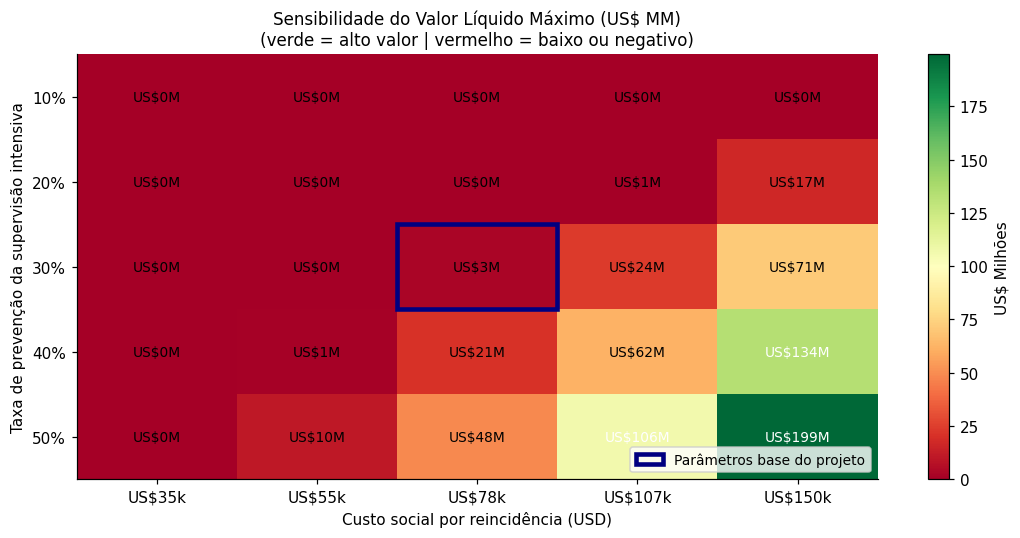

In [37]:
# =============================================================================
# ANÁLISE DE SENSIBILIDADE — Valor Líquido Máximo
# Variando taxa de prevenção e custo social por crime
# =============================================================================

taxas_prev  = [0.10, 0.20, 0.30, 0.40, 0.50]
custos_crim = [35_000, 55_000, 78_000, 107_000, 150_000]

matriz_vl = np.zeros((len(taxas_prev), len(custos_crim)))

for i, taxa in enumerate(taxas_prev):
    for j, custo_c in enumerate(custos_crim):
        benef_por_tp = custo_c * taxa
        vls_temp = []
        for _, row in df_kpi.iterrows():
            b = row['TP'] * benef_por_tp
            c = row['n_supervisionados'] * CUSTOS['custo_incremental_supervisao'] * PERIODO_ANOS
            vls_temp.append((b - c) / 1e6)
        matriz_vl[i, j] = max(vls_temp)

fig, ax = plt.subplots(figsize=(10, 5))
im = ax.imshow(matriz_vl, cmap='RdYlGn', aspect='auto')

ax.set_xticks(range(len(custos_crim)))
ax.set_xticklabels([f'US${c//1000:.0f}k' for c in custos_crim])
ax.set_yticks(range(len(taxas_prev)))
ax.set_yticklabels([f'{t*100:.0f}%' for t in taxas_prev])
ax.set_xlabel('Custo social por reincidência (USD)', fontsize=10)
ax.set_ylabel('Taxa de prevenção da supervisão intensiva', fontsize=10)
ax.set_title(
    'Sensibilidade do Valor Líquido Máximo (US$ MM)\n'
    '(verde = alto valor | vermelho = baixo ou negativo)',
    fontsize=11
)

for i in range(len(taxas_prev)):
    for j in range(len(custos_crim)):
        ax.text(j, i, f'US${matriz_vl[i,j]:.0f}M',
                ha='center', va='center', fontsize=9,
                color='white' if abs(matriz_vl[i,j]) > 80 else 'black')

# Marcar parâmetros base do projeto
idx_t_base = taxas_prev.index(CUSTOS['taxa_prevencao'])
idx_c_base = custos_crim.index(CUSTOS['custo_por_reincidencia'])
ax.add_patch(plt.Rectangle(
    (idx_c_base - 0.5, idx_t_base - 0.5), 1, 1,
    fill=False, edgecolor='navy', linewidth=3,
    label='Parâmetros base do projeto'
))
ax.legend(fontsize=9, loc='lower right')
plt.colorbar(im, ax=ax, label='US$ Milhões')
plt.tight_layout()
plt.show()


## 6. Análise por Decil de Risco

Divide a amostra de teste em 10 grupos de igual tamanho, ordenados do maior risco para o menor (score crescente). Permite responder: *se supervisionarmos apenas os X% de maior risco, quantos reincidentes capturamos e qual o custo-benefício?*

**Como interpretar a tabela:**
- **Decil 1** = os 10% com maior risco (menor score P(Não Reincidiu))
- **% Reincid. no decil**: concentração de reincidentes naquele grupo — quanto maior, mais o modelo discrimina
- **% Capturados (acum.)**: curva de captura acumulada — com os K primeiros decis, quantos reincidentes totais capturamos
- **Valor líquido (acum.)**: se supervisionarmos todos até aquele decil, qual o resultado financeiro

**Como interpretar os gráficos:**
- **Concentração de risco:** barras vermelhas indicam decis com concentração acima da média (57,7%). O ideal é que o primeiro decil tenha concentração muito acima da média e os últimos, muito abaixo
- **Curva de captura acumulada:** quanto mais afastada da diagonal cinza (aleatório), melhor o modelo discrimina
- **Valor líquido por decil:** mostra até que decil vale a pena supervisionar do ponto de vista do custo-benefício


       Score max    N  % Reinc. no decil  % Capturados (acum.)  Reinc. evitadas (acum.)  Custo acum. (US$MM)  Beneficio acum. (US$MM)  Valor liquido (US$MM)
Decil                                                                                                                                                       
1          0.242  775               86.8                  15.1                    202.0                 13.9                     15.7                    1.8
2          0.297  775               82.1                  29.3                    393.0                 27.9                     30.6                    2.7
3          0.346  775               72.6                  41.9                    562.0                 41.9                     43.8                    2.0
4          0.386  775               68.4                  53.7                    721.0                 55.8                     56.2                    0.4
5          0.426  775               62.8                  

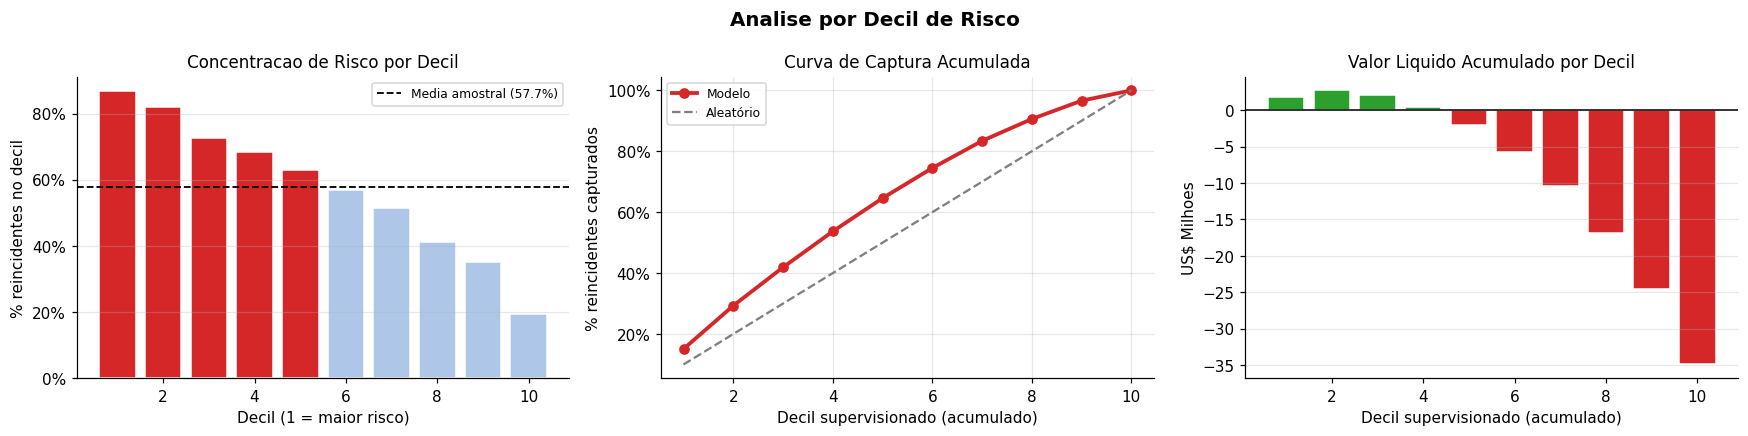

In [38]:
# =============================================================================
# ANALISE POR DECIL DE RISCO
# =============================================================================

ordem     = np.argsort(y_proba)
y_ord     = y_true[ordem]
proba_ord = y_proba[ordem]
n_tot_reinc = (y_true == 0).sum()

rows_decil = []
acum_reinc = 0
for d in range(1, 11):
    ini = int((d-1)/10 * n_total)
    fim = int(d/10    * n_total)
    bloco        = y_ord[ini:fim]
    n_bloco      = fim - ini
    reinc_bloco  = int((bloco == 0).sum())
    acum_reinc  += reinc_bloco
    score_max    = float(proba_ord[fim-1])
    pct_reinc    = reinc_bloco / n_bloco * 100
    pct_capturad = acum_reinc  / n_tot_reinc * 100
    n_sup_acum   = fim
    reinc_evit   = acum_reinc * CUSTOS['taxa_prevencao']
    benef_acum   = reinc_evit * CUSTOS['custo_por_reincidencia']
    custo_acum   = n_sup_acum * CUSTOS['custo_incremental_supervisao'] * PERIODO_ANOS
    vliq_acum    = benef_acum - custo_acum
    rows_decil.append({
        'Decil'                   : d,
        'Score max'               : round(score_max, 3),
        'N'                       : n_bloco,
        '% Reinc. no decil'       : round(pct_reinc, 1),
        '% Capturados (acum.)'    : round(pct_capturad, 1),
        'Reinc. evitadas (acum.)' : round(reinc_evit, 0),
        'Custo acum. (US$MM)'     : round(custo_acum/1e6, 1),
        'Beneficio acum. (US$MM)' : round(benef_acum/1e6, 1),
        'Valor liquido (US$MM)'   : round(vliq_acum/1e6, 1),
    })

df_decil = pd.DataFrame(rows_decil).set_index('Decil')
print(df_decil.to_string())

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle('Analise por Decil de Risco', fontsize=13, fontweight='bold')

# Concentracao de risco
axes[0].bar(df_decil.index, df_decil['% Reinc. no decil'],
            color=['#d62728' if v > 57.7 else '#aec7e8'
                   for v in df_decil['% Reinc. no decil']],
            edgecolor='white')
axes[0].axhline(57.7, color='black', linestyle='--', linewidth=1.2,
                label='Media amostral (57.7%)')
axes[0].set_xlabel('Decil (1 = maior risco)')
axes[0].set_ylabel('% reincidentes no decil')
axes[0].set_title('Concentracao de Risco por Decil')
axes[0].yaxis.set_major_formatter(mtick.PercentFormatter())
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3, axis='y')

# Curva de captura acumulada
axes[1].plot(df_decil.index, df_decil['% Capturados (acum.)'],
             color='#d62728', linewidth=2.5, marker='o', label='Modelo')
axes[1].plot(df_decil.index, [d*10 for d in df_decil.index],
             color='gray', linestyle='--', linewidth=1.5, label='Aleatório')
axes[1].set_xlabel('Decil supervisionado (acumulado)')
axes[1].set_ylabel('% reincidentes capturados')
axes[1].set_title('Curva de Captura Acumulada')
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter())
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3)

# Valor liquido acumulado
cores_vl = ['#2ca02c' if v >= 0 else '#d62728'
            for v in df_decil['Valor liquido (US$MM)']]
axes[2].bar(df_decil.index, df_decil['Valor liquido (US$MM)'],
            color=cores_vl, edgecolor='white')
axes[2].axhline(0, color='black', linewidth=1)
axes[2].set_xlabel('Decil supervisionado (acumulado)')
axes[2].set_ylabel('US$ Milhoes')
axes[2].set_title('Valor Liquido Acumulado por Decil')
axes[2].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()
